# Actividad - Proyecto práctico


> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar entregar el trabajo en la presente notebook.
*   Alumno 1: Emma Oitaven Carracedo
*   Alumno 2: Ramiro Rivas Fernández
*   Alumno 3: Víctor Rodríguez Rodríguez
*   Alumno 4: Nicolás Zamorano Ramírez






---
## **Preliminares** - Configuración del entorno

> Estas instrucciones documentan el proceso de configuración del entorno de trabajo en local con Windows + Miniconda + VS Code. El proyecto está pensado originalmente para Colab, pero la renderización de gym requiere ejecución en local.

### Pasos seguidos en local (Windows + Miniconda + VS Code)

Se ha creado un environment de conda con Python 3.8 e instalado las librerías en un orden controlado para evitar conflictos de dependencias (TensorFlow y Keras son especialmente sensibles a esto).

```bash
# 1) Crear environment con Python 3.8 (requerido por gym 0.17.3)
conda create --name miar_rl python=3.8 -y
conda activate miar_rl

# 2) Herramientas base
python -m pip install --upgrade pip setuptools wheel

# 3) TensorFlow primero, fijado (evita que keras-rl2 arrastre una versión incompatible)
pip install tensorflow==2.5.3

# 4) Dependencias compatibles
pip install numpy==1.19.5 h5py==3.1.0 Pillow==9.5.0 pyglet==1.5.0
pip install gym==0.17.3

# 5) keras-rl2 sin dependencias (para que no pise TensorFlow)
pip install --no-deps keras-rl2==1.0.5

# 6) Kernel para VS Code
pip install ipykernel
python -m ipykernel install --user --name miar_rl --display-name "Python (miar_rl)"
```

Con esto, basta seleccionar el kernel **"Python (miar_rl)"** desde VS Code al abrir el notebook.

**Nota sobre el entorno Acrobot-v1 del Grupo 1**: al ser un entorno de *Classic Control* (no Atari), no requiere instalar `atari-py` ni gestionar ROMs.

---

In [1]:
# Verificación del entorno: versiones esperadas
import sys
from importlib.metadata import version

print("Python    :", sys.version.split()[0])
print("TensorFlow:", version("tensorflow"))
print("gym       :", version("gym"))
print("keras-rl2 :", version("keras-rl2"))
print("numpy     :", version("numpy"))

Python    : 3.8.20
TensorFlow: 2.5.3
gym       : 0.17.3
keras-rl2 : 1.0.5
numpy     : 1.19.5


---
## **PARTE 1**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondien de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
## **PARTE 2**. Desarrollo y preguntas

#### Importar librerías

In [2]:
# Comprobamos la versión de TensorFlow y si detecta GPU
import tensorflow as tf

print("TF version:", tf.__version__)
print("Keras (tf.keras) version:", tf.keras.__version__)
print("Physical GPUs:", tf.config.list_physical_devices('GPU'))
print("Logical GPUs:", tf.config.list_logical_devices('GPU'))

c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\numpy\.libs\libopenblas.WCDJNK7YVMPZQ2ME2ZZHJJRJ3JIKNDB7.gfortran-win_amd64.dll
c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"
c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TF version: 2.5.3
Keras (tf.keras) version: 2.5.0
Physical GPUs: []
Logical GPUs: []


In [3]:
from __future__ import division

import numpy as np
import gym

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, BoltzmannQPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import Callback, FileLogger, ModelIntervalCheckpoint
import matplotlib.pyplot as plt
import matplotlib as mpl

#### Configuración base

In [4]:
# Configuración base para Acrobot-v1
env_name = 'Acrobot-v1'
env = gym.make(env_name)

np.random.seed(123)
env.seed(123)

INPUT_SHAPE = env.observation_space.shape   # (6,) — vector de estado, no imagen
WINDOW_LENGTH = 1                            # Acrobot es Markov puro
nb_actions = env.action_space.n              # 3 acciones: torque {-1, 0, +1}

print(f"Entorno: {env_name}")
print(f"Espacio de observación: {env.observation_space}")
print(f"Espacio de acciones: {env.action_space} -> {nb_actions} acciones")
print(f"INPUT_SHAPE: {INPUT_SHAPE}, WINDOW_LENGTH: {WINDOW_LENGTH}")

Entorno: Acrobot-v1
Espacio de observación: Box(-28.274333953857422, 28.274333953857422, (6,), float32)
Espacio de acciones: Discrete(3) -> 3 acciones
INPUT_SHAPE: (6,), WINDOW_LENGTH: 1


In [5]:
class AcrobotProcessor(Processor):
    """Procesador para Acrobot-v1.
    
    Normaliza las dos velocidades angulares dividiéndolas por su rango máximo
    (4π y 9π rad/s respectivamente) para que todo el vector de observación
    quede en [-1, 1]. Las 4 primeras componentes (cos/sin de los ángulos)
    ya están naturalmente en ese rango.
    
    No procesa imágenes (la observación es un vector de 6 floats) ni recorta
    la recompensa (que ya está acotada en {-1, 0} por el propio entorno).
    """
    
    THETA1_DOT_MAX = 4 * np.pi   # ≈ 12.566 rad/s, rango de la 5ª componente
    THETA2_DOT_MAX = 9 * np.pi   # ≈ 28.274 rad/s, rango de la 6ª componente

    def process_observation(self, observation):
        assert observation.shape == (6,)
        obs = np.asarray(observation, dtype=np.float32).copy()
        obs[4] /= self.THETA1_DOT_MAX
        obs[5] /= self.THETA2_DOT_MAX
        return obs

    def process_state_batch(self, batch):
        # El batch ya viene normalizado desde process_observation.
        # Solo aseguramos dtype float32 para el modelo Keras.
        return batch.astype('float32')

    # process_reward NO se redefine: la recompensa nativa de Acrobot
    # ya está en {-1, 0}, no necesita clipping ni transformación.

### Búsqueda manual de hiperparámetros sobre el baseline

Búsqueda dirigida de 5 combinaciones de hiperparámetros sobre la configuración **DQN baseline** con el objetivo de acercar su recompensa media al umbral oficial de "resuelto" (-100) que aparece en la documentación de Gymnasium para Acrobot-v1.

La búsqueda se centra en las tres dimensiones con mayor impacto teórico en DQN:

- **Tamaño de red** (`hidden_size`): 64 vs 128 neuronas por capa oculta.
- **Learning rate** del optimizador Adam.
- **Batch size** para la actualización por replay.
- **Número de pasos de entrenamiento** (proxy de tiempo de refinamiento post-exploración).

El diseño de trials permite aislar el efecto de cada dimensión mediante comparaciones por pares: `B0 vs B1` mide el efecto puro de aumentar la red; `B0 vs B2` el efecto puro de aumentar los pasos, etc.

Cada trial usa la misma semilla (`SEED=123`) que el resto del proyecto para reproducibilidad. Un único seed por trial es suficiente para una primera exploración; si algún trial destaca claramente, se puede confirmar posteriormente con seeds adicionales.


In [6]:
# === Búsqueda de hiperparámetros: infraestructura ===
import time
import os

LOG_DIR = 'logs'
WEIGHTS_DIR = 'weights'
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

def build_q_model_flex(input_shape, nb_actions, window_length=1, hidden_size=64):
    """Como build_q_model pero con tamaño de capa configurable.
    
    Mantiene la restricción de que layers[-2] sea la última capa densa
    de features (necesario para que enable_dueling_network funcione,
    aunque en esta búsqueda solo usamos el baseline sin dueling).
    """
    model = Sequential()
    model.add(Flatten(input_shape=(window_length,) + input_shape))
    model.add(Dense(hidden_size, activation='relu'))
    model.add(Dense(hidden_size, activation='relu'))
    model.add(Dense(nb_actions, activation='linear'))
    return model


def build_agent_flex(model, processor, learning_rate=1e-3, batch_size=64):
    """DQNAgent baseline (sin double ni dueling) con LR y batch_size configurables.
    
    El resto de hiperparámetros se mantienen fijos en los valores del
    experimento principal para que la comparación sea justa.
    """
    memory = SequentialMemory(limit=200000, window_length=WINDOW_LENGTH)
    policy = LinearAnnealedPolicy(
        EpsGreedyQPolicy(), attr='eps',
        value_max=1.0, value_min=0.05, value_test=0.0, nb_steps=10000
    )
    dqn = DQNAgent(
        model=model, nb_actions=nb_actions, memory=memory, processor=processor,
        policy=policy, nb_steps_warmup=1000, gamma=0.99,
        target_model_update=1e-2, train_interval=4, batch_size=batch_size,
        enable_double_dqn=False, enable_dueling_network=False,
    )
    dqn.compile(Adam(learning_rate=learning_rate), metrics=['mae'])
    return dqn


def evaluate_trial(dqn, seed=123, n_episodes=100):
    """Evaluación silenciosa de un agente sobre n_episodes.
    
    Usa un entorno propio (no el global) para no interferir con la
    evaluación oficial de las 4 configuraciones que ya está más arriba.
    """
    env_eval = gym.make(env_name)
    env_eval.seed(seed)
    np.random.seed(seed)
    hist = dqn.test(env_eval, nb_episodes=n_episodes, visualize=False, verbose=0)
    rewards = np.array(hist.history['episode_reward'])
    env_eval.close()
    return {
        'mean_reward': float(rewards.mean()),
        'std_reward':  float(rewards.std()),
        'min_reward':  float(rewards.min()),
        'max_reward':  float(rewards.max()),
        'solved':      int(np.sum(rewards > -500)),
    }


def run_trial(name, hidden_size, learning_rate, batch_size, nb_steps, seed=123):
    """Entrena y evalúa un trial. Devuelve dict con métricas y guarda log en logs/search_<name>_log.json."""
    print(f"\n--- Trial: {name} ---")
    print(f"  hidden={hidden_size}, lr={learning_rate}, batch={batch_size}, steps={nb_steps}")
    
    # Control de semillas (idéntico a train_config)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    env_local = gym.make(env_name)
    env_local.seed(seed)
    
    # Construir modelo y agente con los HP del trial
    model = build_q_model_flex(INPUT_SHAPE, nb_actions, WINDOW_LENGTH, hidden_size)
    processor = AcrobotProcessor()
    dqn = build_agent_flex(model, processor, learning_rate, batch_size)
    
    # Log a fichero propio del trial (no colisiona con los del experimento principal)
    log_path = os.path.join(LOG_DIR, f'search_{name}_log.json')
    callbacks = [FileLogger(log_path, interval=100)]
    
    t0 = time.time()
    dqn.fit(env_local, nb_steps=nb_steps, callbacks=callbacks,
            log_interval=max(nb_steps // 5, 10000),
            visualize=False, verbose=1)
    train_time = time.time() - t0
    env_local.close()
    
    # Evaluar sobre 100 episodios de test
    metrics = evaluate_trial(dqn, seed=seed)
    metrics.update({
        'name': name, 'train_time': train_time,
        'hidden_size': hidden_size, 'learning_rate': learning_rate,
        'batch_size': batch_size, 'nb_steps': nb_steps,
    })
    print(f"  -> reward = {metrics['mean_reward']:+.1f} +/- {metrics['std_reward']:.1f}, "
          f"solved = {metrics['solved']}/100, "
          f"time = {train_time:.0f}s")
    return metrics


In [7]:
# === Definición de los 5 trials ===
# Diseñados para aislar el efecto de cada hiperparámetro por comparación de pares:
#   (B0 vs B1): efecto puro de red mayor (64 -> 128)
#   (B0 vs B2): efecto puro de más pasos (100k -> 200k)
#   (B1 vs B4): efecto del batch mayor + pasos
#   B3: LR menor con red y batch mayores (candidato conservador)
#   B4: combinación "todo mejor" (candidato agresivo)
TRIALS = [
    {'name': 'B0_baseline_ref', 'hidden_size':  64, 'learning_rate': 1e-3, 'batch_size': 32, 'nb_steps': 100000},
    {'name': 'B1_bigger_net',   'hidden_size': 128, 'learning_rate': 1e-3, 'batch_size': 32, 'nb_steps': 100000},
    {'name': 'B2_more_steps',   'hidden_size':  64, 'learning_rate': 1e-3, 'batch_size': 32, 'nb_steps': 200000},
    {'name': 'B3_lr_low',       'hidden_size': 128, 'learning_rate': 5e-4, 'batch_size': 64, 'nb_steps': 150000},
    {'name': 'B4_all_better',   'hidden_size': 128, 'learning_rate': 1e-3, 'batch_size': 64, 'nb_steps': 200000},
]

# Ejecutar todos los trials
search_results = []
for trial in TRIALS:
    metrics = run_trial(**trial)
    search_results.append(metrics)

# Resumen ordenado por reward medio (mejor primero)
print("\n" + "="*80)
print("RESUMEN DE LA BÚSQUEDA (ordenado por reward medio, mejor primero):")
print("="*80)
print(f"{'Trial':<20s} {'reward':>12s} {'std':>7s} {'solved':>9s} {'time':>7s}")
print("-"*80)
for r in sorted(search_results, key=lambda r: -r['mean_reward']):
    print(f"  {r['name']:<20s}  {r['mean_reward']:+8.1f}  {r['std_reward']:6.1f}  "
          f"{r['solved']:>4d}/100  {r['train_time']:>5.0f}s")

# Identificar y guardar el mejor conjunto de HP
best_trial = max(search_results, key=lambda r: r['mean_reward'])
print(f"\n[MEJOR] {best_trial['name']}: reward = {best_trial['mean_reward']:+.1f}, "
      f"solved = {best_trial['solved']}/100")
print(f"  Hiperparámetros ganadores: hidden={best_trial['hidden_size']}, "
      f"lr={best_trial['learning_rate']}, batch={best_trial['batch_size']}, "
      f"steps={best_trial['nb_steps']}")



--- Trial: B0_baseline_ref ---
  hidden=64, lr=0.001, batch=32, steps=100000
Training for 100000 steps ...
Interval 1 (0 steps performed)
  552/20000 [..............................] - ETA: 7s - reward: -1.0000

c:\Users\victo\miniconda3\envs\miar_rl\lib\site-packages\tensorflow\python\keras\engine\training.py:2424: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  warnings.warn('`Model.state_updates` will be removed in a future version. '


20000/20000 [==============================] - 18s 914us/step - reward: -0.9985
50 episodes - episode_reward: -395.680 [-500.000, -127.000] - loss: 0.429 - mae: 12.465 - mean_q: -18.420 - mean_eps: 0.252

Interval 2 (20000 steps performed)
20000/20000 [==============================] - 20s 980us/step - reward: -0.9963
76 episodes - episode_reward: -260.803 [-500.000, -101.000] - loss: 1.988 - mae: 28.873 - mean_q: -42.593 - mean_eps: 0.050

Interval 3 (40000 steps performed)
20000/20000 [==============================] - 20s 1ms/step - reward: -0.9944
111 episodes - episode_reward: -180.288 [-414.000, -83.000] - loss: 2.987 - mae: 35.582 - mean_q: -52.349 - mean_eps: 0.050

Interval 4 (60000 steps performed)
20000/20000 [==============================] - 20s 1ms/step - reward: -0.9936
128 episodes - episode_reward: -156.156 [-315.000, -80.000] - loss: 3.450 - mae: 36.482 - mean_q: -53.479 - mean_eps: 0.050

Interval 5 (80000 steps performed)
20000/20000 [==============================]

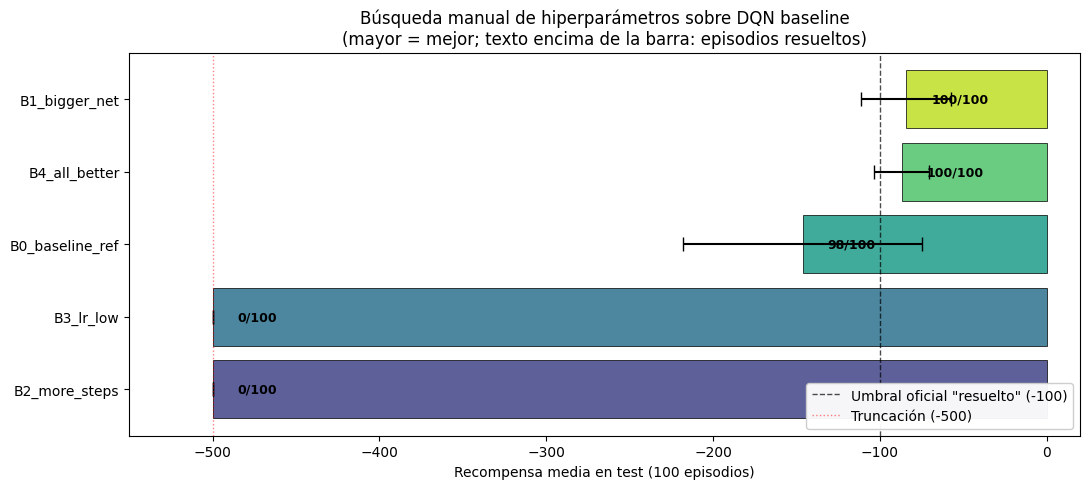

In [9]:
# === Gráfica: comparativa de trials de la búsqueda de hiperparámetros ===
os.makedirs('plots', exist_ok=True)
fig, ax = plt.subplots(figsize=(11, 5))

# Ordenar por reward medio (peor abajo, mejor arriba)
results_sorted = sorted(search_results, key=lambda r: r['mean_reward'])
names   = [r['name'] for r in results_sorted]
rewards = [r['mean_reward'] for r in results_sorted]
stds    = [r['std_reward']  for r in results_sorted]
solved  = [r['solved']      for r in results_sorted]

# Colormap discreto: viridis del peor al mejor
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results_sorted)))
bars = ax.barh(names, rewards, xerr=stds, color=colors, alpha=0.85,
               edgecolor='black', linewidth=0.6, capsize=5)

# Líneas de referencia
ax.axvline(-100, color='black', linestyle='--', linewidth=1, alpha=0.7,
           label='Umbral oficial "resuelto" (-100)')
ax.axvline(-500, color='red', linestyle=':', linewidth=1, alpha=0.5,
           label='Truncación (-500)')

# Anotar cada barra con nº de episodios resueltos
for bar, r, s in zip(bars, rewards, solved):
    ax.text(min(r + 15, -20), bar.get_y() + bar.get_height()/2,
            f'{s}/100', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Recompensa media en test (100 episodios)')
ax.set_title('Búsqueda manual de hiperparámetros sobre DQN baseline\n'
             '(mayor = mejor; texto encima de la barra: episodios resueltos)')
ax.set_xlim(-550, 20)
ax.legend(loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.savefig('plots/04_hp_search.png', dpi=120, bbox_inches='tight')
plt.show()


1. Implementación de la red neuronal

In [10]:
def build_q_model(input_shape, nb_actions, window_length=1):
    """Construye la red Q(s, a) para Acrobot.
    
    Arquitectura MLP 6 → 64 → 64 → 3 con activaciones ReLU.
    
    IMPORTANTE: Dense y Activation están combinados (no separados) para que
    model.layers[-2] sea la última capa densa de features (64 neuronas).
    Esto es requisito de keras-rl2 para que enable_dueling_network funcione
    correctamente, ya que el agente reemplaza todo lo que viene después de
    layers[-2] por las cabezas V(s) y A(s,a).
    """
    model = Sequential()
    model.add(Flatten(input_shape=(window_length,) + input_shape))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(128, activation='relu'))   # <- layers[-2]: features para Dueling
    model.add(Dense(nb_actions, activation='linear'))  # <- layers[-1]: Q-valores
    return model

# Verificación de la arquitectura. Usamos una semilla aislada (99) para que
# este demo no consuma la aleatoriedad de TF que luego usarán los entrenamientos.
tf.random.set_seed(99)
_demo_model = build_q_model(INPUT_SHAPE, nb_actions, WINDOW_LENGTH)
print(_demo_model.summary())
print(f"\nlayers[-2] = {_demo_model.layers[-2].name} "
      f"(output shape: {_demo_model.layers[-2].output_shape})")
del _demo_model

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_5 (Flatten)          (None, 6)                 0         
_________________________________________________________________
dense_15 (Dense)             (None, 128)               896       
_________________________________________________________________
dense_16 (Dense)             (None, 128)               16512     
_________________________________________________________________
dense_17 (Dense)             (None, 3)                 387       
Total params: 17,795
Trainable params: 17,795
Non-trainable params: 0
_________________________________________________________________
None

layers[-2] = dense_16 (output shape: (None, 128))


2. Implementación de la solución DQN

In [11]:
def build_agent(model, processor,
                enable_double_dqn=False,
                enable_dueling_network=False,
                dueling_type='avg'):
    """Construye un DQNAgent configurable.
    
    Los hiperparámetros base son idénticos para las 4 configuraciones del
    estudio; solo varían los dos flags enable_double_dqn y enable_dueling_network.
    """
    memory = SequentialMemory(limit=200000, window_length=WINDOW_LENGTH)
    
    policy = LinearAnnealedPolicy(
        EpsGreedyQPolicy(),
        attr='eps',
        value_max=1.0,    # exploración inicial total
        value_min=0.05,   # exploración residual al final
        value_test=0.0,   # greedy puro en test
        nb_steps=10000    # decaimiento lineal durante los primeros 10k steps
    )
    
    dqn = DQNAgent(
        model=model,
        nb_actions=nb_actions,
        memory=memory,
        processor=processor,
        policy=policy,
        nb_steps_warmup=1000,
        gamma=0.99,
        target_model_update=1e-2,   # soft update (Polyak)
        train_interval=4,
        batch_size=64,
        enable_double_dqn=enable_double_dqn,
        enable_dueling_network=enable_dueling_network,
        dueling_type=dueling_type,
    )
    dqn.compile(Adam(learning_rate=1e-3), metrics=['mae'])
    return dqn

In [12]:
from rl.callbacks import ModelIntervalCheckpoint

NB_TRAIN_STEPS = 200000   # ajustado según búsqueda de hiperparámetros (Trial B4)
CHECKPOINT_INTERVAL = 40000   # cada cuántos pasos se guarda un snapshot del modelo


def train_config(config_name, **agent_kwargs):
    """Entrena una configuración de DQN sobre Acrobot-v1.
    
    Devuelve (dqn, history) y guarda en disco:
      - logs/dqn_<config>_log.json                 : log episodio a episodio (para gráficas)
      - weights/dqn_<config>_weights.h5f           : pesos finales del modelo
      - weights/dqn_<config>_ckpt_<step>.h5f       : snapshots del modelo cada
                                                     CHECKPOINT_INTERVAL pasos, necesarios
                                                     para generar el vídeo de evolución del
                                                     aprendizaje (obligatorio para el entregable).
    """
    print(f"\n{'='*60}\n  Entrenando configuración: {config_name}\n{'='*60}")
    
    # Control completo de semillas: numpy + tensorflow + entorno.
    # tf.random.set_seed garantiza que cada config arranca con LOS MISMOS
    # pesos iniciales en la red, eliminando la varianza por inicialización.
    SEED = 123
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    env_local = gym.make(env_name)
    env_local.seed(SEED)
    
    # Cada config construye su propia red (con pesos reproducibles por la seed)
    model = build_q_model(INPUT_SHAPE, nb_actions, WINDOW_LENGTH)
    processor = AcrobotProcessor()
    dqn = build_agent(model, processor, **agent_kwargs)
    
    log_filename = os.path.join(LOG_DIR, f'dqn_{config_name}_log.json')
    weights_filename = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_weights.h5f')
    # Patrón con {step} para que keras-rl reemplace el número de paso al guardar
    ckpt_pattern = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_ckpt_{{step}}.h5f')
    
    callbacks = [
        FileLogger(log_filename, interval=100),
        ModelIntervalCheckpoint(ckpt_pattern, interval=CHECKPOINT_INTERVAL),
    ]
    
    history = dqn.fit(env_local, nb_steps=NB_TRAIN_STEPS,
                      callbacks=callbacks,
                      log_interval=10000,
                      visualize=False, verbose=1)
    
    dqn.save_weights(weights_filename, overwrite=True)
    print(f"\n[OK] Pesos finales guardados en {weights_filename}")
    print(f"[OK] Log guardado en {log_filename}")
    print(f"[OK] Checkpoints intermedios en {WEIGHTS_DIR}/dqn_{config_name}_ckpt_*.h5f")
    
    return dqn, history


In [13]:
# Configuración 1: DQN baseline (vanilla)
dqn_baseline, hist_baseline = train_config(
    'baseline'
)

# Configuración 2: Double DQN
dqn_double, hist_double = train_config(
    'double',
    enable_double_dqn=True
)

# Configuración 3: Dueling DQN
dqn_dueling, hist_dueling = train_config(
    'dueling',
    enable_dueling_network=True,
    dueling_type='avg'
)

# Configuración 4: Double + Dueling DQN
dqn_double_dueling, hist_double_dueling = train_config(
    'double_dueling',
    enable_double_dqn=True,
    enable_dueling_network=True,
    dueling_type='avg'
)

print("\n[OK] Entrenamiento completado para las 4 configuraciones.")


  Entrenando configuración: baseline
Training for 200000 steps ...
Interval 1 (0 steps performed)
10000/10000 [==============================] - 11s 1ms/step - reward: -1.0000
20 episodes - episode_reward: -500.000 [-500.000, -500.000] - loss: 0.100 - mae: 6.715 - mean_q: -9.930 - mean_eps: 0.477

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 12s 1ms/step - reward: -0.9960
43 episodes - episode_reward: -226.674 [-500.000, -95.000] - loss: 0.742 - mae: 17.834 - mean_q: -26.348 - mean_eps: 0.050

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 12s 1ms/step - reward: -0.9933
67 episodes - episode_reward: -150.597 [-494.000, -83.000] - loss: 1.611 - mae: 24.821 - mean_q: -36.353 - mean_eps: 0.050

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 12s 1ms/step - reward: -0.9919
81 episodes - episode_reward: -123.012 [-219.000, -78.000] - loss: 2.131 - mae: 28.102 - mean_q: -40.921 - mean_e

In [14]:
# Evaluación de las 4 configuraciones sobre 100 episodios de test
TEST_EPISODES = 100

def evaluate(dqn, name, seed=123):
    print(f"\n--- Evaluando: {name} ---")
    # Resetear semillas antes de CADA test para que las 4 configs vean
    # exactamente los mismos 100 episodios (comparativa justa).
    env.seed(seed)
    np.random.seed(seed)
    history = dqn.test(env, nb_episodes=TEST_EPISODES, visualize=False, verbose=0)
    rewards = np.array(history.history['episode_reward'])
    steps = np.array(history.history['nb_steps'])
    solved = int(np.sum(rewards > -500))
    print(f"  Recompensa media   : {rewards.mean():.2f} ± {rewards.std():.2f}")
    print(f"  Recompensa min/max : {rewards.min():.0f} / {rewards.max():.0f}")
    print(f"  Pasos medios/epis. : {steps.mean():.1f}")
    print(f"  Episodios resueltos: {solved}/{TEST_EPISODES} "
          f"({100*solved/TEST_EPISODES:.0f}%)")
    return rewards

rewards_baseline       = evaluate(dqn_baseline,       'DQN baseline')
rewards_double         = evaluate(dqn_double,         'Double DQN')
rewards_dueling        = evaluate(dqn_dueling,        'Dueling DQN')
rewards_double_dueling = evaluate(dqn_double_dueling, 'Double + Dueling DQN')


--- Evaluando: DQN baseline ---
  Recompensa media   : -83.18 ± 16.76
  Recompensa min/max : -157 / -61
  Pasos medios/epis. : 84.2
  Episodios resueltos: 100/100 (100%)

--- Evaluando: Double DQN ---
  Recompensa media   : -85.91 ± 18.93
  Recompensa min/max : -159 / -62
  Pasos medios/epis. : 86.9
  Episodios resueltos: 100/100 (100%)

--- Evaluando: Dueling DQN ---
  Recompensa media   : -86.80 ± 16.69
  Recompensa min/max : -164 / -62
  Pasos medios/epis. : 87.8
  Episodios resueltos: 100/100 (100%)

--- Evaluando: Double + Dueling DQN ---
  Recompensa media   : -83.81 ± 18.86
  Recompensa min/max : -229 / -61
  Pasos medios/epis. : 84.8
  Episodios resueltos: 100/100 (100%)


### Generación del vídeo MP4 de evolución del aprendizaje

Para cumplir con el requisito de entregable, se genera para cada configuración un **vídeo MP4** que muestra la evolución del agente a lo largo del entrenamiento, cargando los snapshots del modelo guardados cada `CHECKPOINT_INTERVAL` pasos y ejecutando un episodio de test con cada uno.

El vídeo se genera mediante el wrapper `gym.wrappers.Monitor`, que graba automáticamente cada paso del entorno al MP4 mientras el agente actúa. Los MP4 intermedios de cada checkpoint se concatenan en un vídeo final por configuración con `moviepy`.

**Dependencias**: es necesario tener instalados `imageio`, `imageio-ffmpeg` y `moviepy`. Si no lo están, ejecute en un terminal del entorno:

```bash
pip install imageio imageio-ffmpeg moviepy
```

En el vídeo final se aprecia visualmente cómo el agente evoluciona: en los checkpoints tempranos (40k, 80k) el péndulo suele oscilar sin conseguir alcanzar la altura objetivo (episodio truncado a 500 pasos, recompensa −500), mientras que en los checkpoints tardíos (160k, 200k) el agente resuelve rápidamente (~60-100 pasos, recompensa ≈ −80).


In [17]:
# === Generación del vídeo MP4 de evolución del aprendizaje ===
import numpy as np
import imageio
from PIL import Image, ImageDraw, ImageFont

VIDEOS_DIR = 'videos'
os.makedirs(VIDEOS_DIR, exist_ok=True)


def _make_title_frame(text, size=(500, 500)):
    """Crea un frame estático con texto centrado (portada de segmento del vídeo)."""
    img = Image.new('RGB', size, color=(0, 0, 0))
    draw = ImageDraw.Draw(img)
    try:
        font_big = ImageFont.truetype("arial.ttf", 32)
        font_small = ImageFont.truetype("arial.ttf", 24)
    except (IOError, OSError):
        font_big = ImageFont.load_default()
        font_small = ImageFont.load_default()
    
    lines = text.split('\n')
    total_h = sum(30 for _ in lines) + 20
    y = (size[1] - total_h) // 2
    for i, line in enumerate(lines):
        font = font_big if i == 0 else font_small
        try:
            bbox = draw.textbbox((0, 0), line, font=font)
            w = bbox[2] - bbox[0]
        except AttributeError:
            w, _ = draw.textsize(line, font=font)
        x = (size[0] - w) // 2
        draw.text((x, y), line, fill='white', font=font)
        y += 40 if i == 0 else 30
    return np.array(img)


def create_learning_video(config_name, agent_kwargs=None,
                          checkpoints=None, seed=42,
                          title_duration=1.5, fps=25):
    """Genera un MP4 mostrando la evolución del agente a lo largo del entrenamiento.
    
    Para cada checkpoint guardado, carga los pesos correspondientes, ejecuta un
    episodio de test capturando los frames del entorno mediante env.render(),
    y compone un MP4 continuo con imageio, precedido cada segmento por una
    portada estática indicando a qué paso del entrenamiento corresponde.
    
    Este enfoque captura los frames en memoria en lugar de usar
    gym.wrappers.Monitor, evitando problemas de compatibilidad ffmpeg/moviepy
    con la versión antigua de gym (0.17.3) que requiere el proyecto.
    """
    if agent_kwargs is None:
        agent_kwargs = {}
    if checkpoints is None:
        checkpoints = list(range(CHECKPOINT_INTERVAL, NB_TRAIN_STEPS + 1, CHECKPOINT_INTERVAL))
    
    print(f"\n=== Generando vídeo de evolución: {config_name} ===")
    
    # Reconstruir agente con la misma arquitectura y HP
    tf.random.set_seed(99)
    model = build_q_model(INPUT_SHAPE, nb_actions, WINDOW_LENGTH)
    processor = AcrobotProcessor()
    dqn = build_agent(model, processor, **agent_kwargs)
    
    all_frames = []
    title_frames_count = int(title_duration * fps)
    
    for step_num in checkpoints:
        ckpt_path = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_ckpt_{step_num}.h5f')
        if not os.path.exists(ckpt_path + '.index'):
            print(f"  [SKIP] No hay checkpoint en {ckpt_path}")
            continue
        
        # Cargar los pesos del checkpoint
        dqn.load_weights(ckpt_path)
        
        # Crear entorno y ejecutar 1 episodio greedy capturando frames
        env_rec = gym.make(env_name)
        env_rec.seed(seed)
        np.random.seed(seed)
        obs = env_rec.reset()
        
        segment_frames = []
        total_reward = 0.0
        for step in range(500):
            frame = env_rec.render(mode='rgb_array')
            segment_frames.append(frame)
            action = dqn.forward(obs)
            obs, r, done, _ = env_rec.step(action)
            total_reward += r
            if done:
                segment_frames.append(env_rec.render(mode='rgb_array'))
                break
        env_rec.close()
        
        n_steps = len(segment_frames) - 1
        
        # Crear portada del segmento con el mismo tamaño que los frames del entorno
        h, w = segment_frames[0].shape[:2]
        title_text = f"Paso {step_num:>6}\nPuntuacion: {total_reward:+.0f}\nDuracion: {n_steps} pasos"
        title_frame = _make_title_frame(title_text, size=(w, h))
        
        # Añadir la portada estática y luego el episodio
        all_frames.extend([title_frame] * title_frames_count)
        all_frames.extend(segment_frames)
        
        print(f"  [OK] Checkpoint {step_num:>6}: reward = {total_reward:+8.1f}, steps = {n_steps:>3}")
    
    if not all_frames:
        print(f"[ERROR] No se generaron frames para {config_name}")
        return None
    
    # Escribir el MP4 final con imageio (usa imageio-ffmpeg como backend)
    output_path = os.path.join(VIDEOS_DIR, f'dqn_{config_name}_evolucion.mp4')
    print(f"  Escribiendo {len(all_frames)} frames a {output_path}...")
    imageio.mimsave(output_path, all_frames, fps=fps, macro_block_size=1)
    
    print(f"[OK] Video final: {output_path}")
    return output_path

In [18]:
# === Llamadas: un vídeo por configuración ===
video_paths = {}
video_paths['baseline']       = create_learning_video('baseline')
video_paths['double']         = create_learning_video('double',         agent_kwargs={'enable_double_dqn': True})
video_paths['dueling']        = create_learning_video('dueling',        agent_kwargs={'enable_dueling_network': True, 'dueling_type': 'avg'})
video_paths['double_dueling'] = create_learning_video('double_dueling', agent_kwargs={'enable_double_dqn': True, 'enable_dueling_network': True, 'dueling_type': 'avg'})

print("\n" + "="*60)
print("VIDEOS FINALES GENERADOS:")
print("="*60)
for name, path in video_paths.items():
    if path:
        size_mb = os.path.getsize(path) / (1024*1024)
        print(f"  {name:<20s} -> {path}  ({size_mb:.1f} MB)")



=== Generando vídeo de evolución: baseline ===
  [OK] Checkpoint  40000: reward =    -83.0, steps =  84
  [OK] Checkpoint  80000: reward =   -125.0, steps = 126
  [OK] Checkpoint 120000: reward =   -500.0, steps = 500
  [OK] Checkpoint 160000: reward =   -500.0, steps = 500
  [OK] Checkpoint 200000: reward =   -500.0, steps = 500
  Escribiendo 1900 frames a videos\dqn_baseline_evolucion.mp4...
[OK] Video final: videos\dqn_baseline_evolucion.mp4

=== Generando vídeo de evolución: double ===
  [OK] Checkpoint  40000: reward =   -124.0, steps = 125
  [OK] Checkpoint  80000: reward =   -119.0, steps = 120
  [OK] Checkpoint 120000: reward =   -147.0, steps = 148
  [OK] Checkpoint 160000: reward =   -162.0, steps = 163
  [OK] Checkpoint 200000: reward =   -500.0, steps = 500
  Escribiendo 1246 frames a videos\dqn_double_evolucion.mp4...
[OK] Video final: videos\dqn_double_evolucion.mp4

=== Generando vídeo de evolución: dueling ===
  [OK] Checkpoint  40000: reward =    -88.0, steps =  89
  

In [19]:
# === Setup para las gráficas comparativas ===
import json

# Estilo global de las gráficas
plt.style.use('seaborn-whitegrid' if 'seaborn-whitegrid' in plt.style.available else 'default')
mpl.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

# Mapeo unificado de colores y etiquetas (consistente entre las 3 gráficas)
CONFIGS = {
    'baseline':       {'label': 'DQN baseline',         'color': '#7f7f7f'},
    'double':         {'label': 'Double DQN',           'color': '#1f77b4'},
    'dueling':        {'label': 'Dueling DQN',          'color': '#2ca02c'},
    'double_dueling': {'label': 'Double + Dueling DQN', 'color': '#d62728'},
}

# Cargar los logs JSON generados por FileLogger durante el entrenamiento
LOGS = {}
for cfg in CONFIGS:
    with open(f'logs/dqn_{cfg}_log.json', 'r') as f:
        LOGS[cfg] = json.load(f)

# Resumen de lo que se ha cargado
for cfg, log in LOGS.items():
    print(f"  {cfg:18s}: {len(log['episode'])} episodios, "
          f"{log['nb_steps'][-1]:>6} pasos totales")


def smooth(y, window=10):
    """Media móvil simple para suavizar curvas ruidosas (el reward episodio a episodio
    tiene mucha varianza, y el suavizado revela la tendencia subyacente)."""
    y = np.asarray(y, dtype=float)
    if len(y) < window:
        return y
    box = np.ones(window) / window
    return np.convolve(y, box, mode='valid')


# Crear carpeta para guardar las gráficas como PNG (útil para incluirlas
# en informes externos, además de mostrarlas inline en el notebook)
os.makedirs('plots', exist_ok=True)

  baseline          : 1888 episodios, 199929 pasos totales
  double            : 1850 episodios, 199951 pasos totales
  dueling           : 1896 episodios, 199984 pasos totales
  double_dueling    : 1794 episodios, 199989 pasos totales


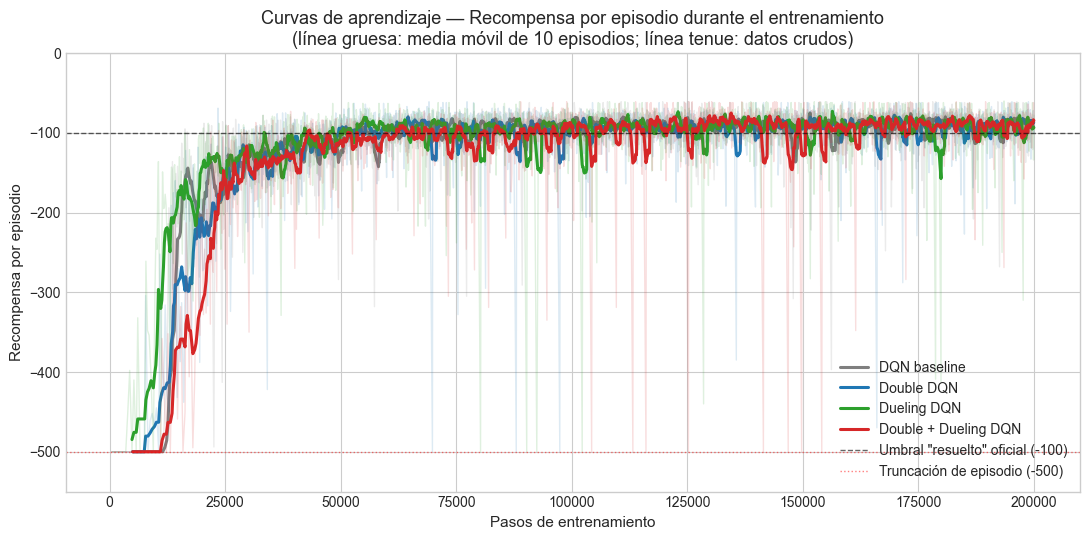

In [20]:
# === Gráfica 1: Curvas de aprendizaje (recompensa por episodio) ===
fig, ax = plt.subplots(figsize=(11, 5.5))

W = 10  # ventana de suavizado en episodios

for cfg, meta in CONFIGS.items():
    log = LOGS[cfg]
    steps = np.asarray(log['nb_steps'])
    rewards = np.asarray(log['episode_reward'])
    
    # Datos crudos en transparencia (muestran la varianza real episodio a episodio)
    ax.plot(steps, rewards, color=meta['color'], alpha=0.15, linewidth=1)
    
    # Curva suavizada destacada (revela la tendencia de aprendizaje)
    if len(rewards) >= W:
        smoothed = smooth(rewards, W)
        steps_smooth = steps[W-1:]
        ax.plot(steps_smooth, smoothed, color=meta['color'],
                linewidth=2.2, label=meta['label'])

# Líneas de referencia
ax.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.6,
           label='Umbral "resuelto" oficial (-100)')
ax.axhline(-500, color='red', linestyle=':', linewidth=1, alpha=0.5,
           label='Truncación de episodio (-500)')

ax.set_xlabel('Pasos de entrenamiento')
ax.set_ylabel('Recompensa por episodio')
ax.set_title('Curvas de aprendizaje — Recompensa por episodio durante el entrenamiento\n'
             '(línea gruesa: media móvil de 10 episodios; línea tenue: datos crudos)')
ax.legend(loc='lower right', framealpha=0.95)
ax.set_ylim(-550, 0)
plt.tight_layout()
plt.savefig('plots/01_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

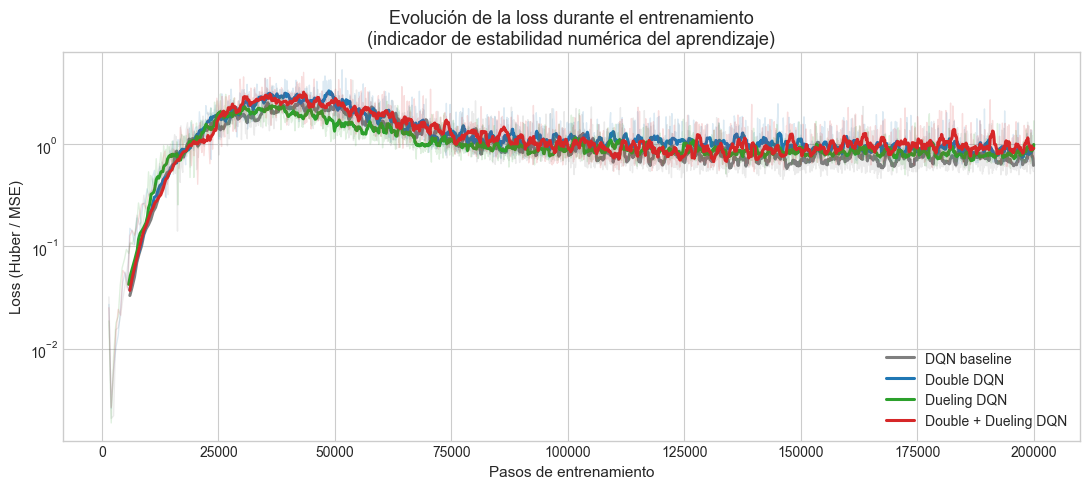

In [21]:
# === Gráfica 2: Evolución de la loss durante el entrenamiento ===
fig, ax = plt.subplots(figsize=(11, 5))

W = 10

for cfg, meta in CONFIGS.items():
    log = LOGS[cfg]
    steps = np.asarray(log['nb_steps'])
    losses = np.asarray(log['loss'])
    
    # Filtrar posibles NaN (ocurren en los primeros episodios antes del warmup)
    mask = ~np.isnan(losses)
    steps_v, losses_v = steps[mask], losses[mask]
    
    ax.plot(steps_v, losses_v, color=meta['color'], alpha=0.15, linewidth=1)
    if len(losses_v) >= W:
        ax.plot(steps_v[W-1:], smooth(losses_v, W), color=meta['color'],
                linewidth=2.2, label=meta['label'])

ax.set_xlabel('Pasos de entrenamiento')
ax.set_ylabel('Loss (Huber / MSE)')
ax.set_title('Evolución de la loss durante el entrenamiento\n'
             '(indicador de estabilidad numérica del aprendizaje)')
ax.legend(loc='lower right', framealpha=0.95)
ax.set_yscale('log')  # escala logarítmica porque la loss crece varios órdenes de magnitud
plt.tight_layout()
plt.savefig('plots/02_loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()

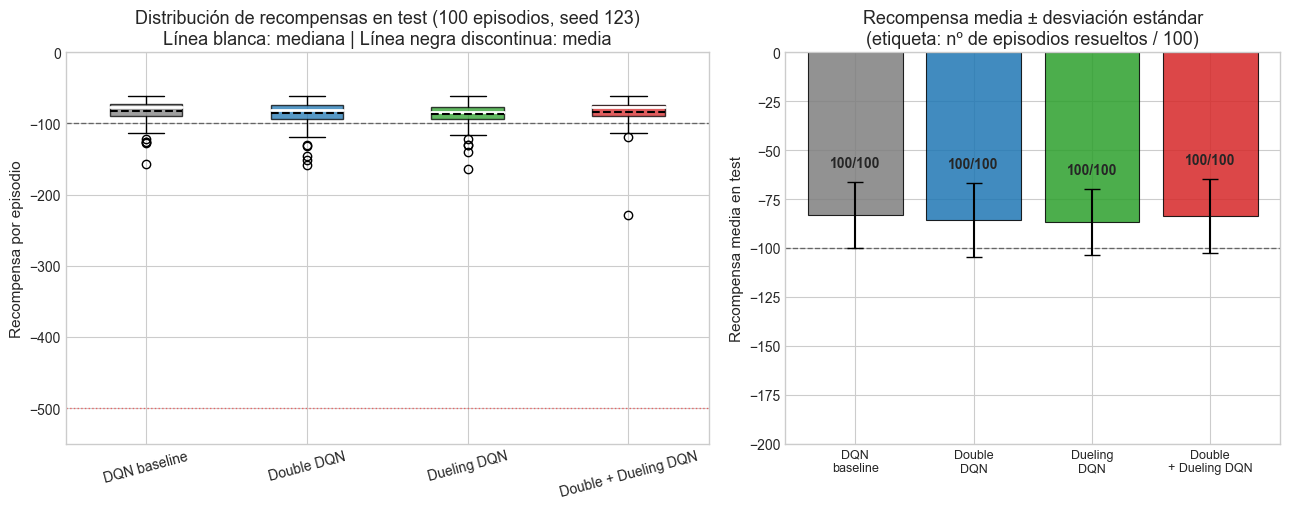

In [22]:
# === Gráfica 3: Distribución de recompensas en los 100 episodios de test ===
fig, (ax_box, ax_bar) = plt.subplots(1, 2, figsize=(13, 5.2),
                                       gridspec_kw={'width_ratios': [1.3, 1]})

# --- Panel izquierdo: boxplot ---
data_test = {
    'baseline':       rewards_baseline,
    'double':         rewards_double,
    'dueling':        rewards_dueling,
    'double_dueling': rewards_double_dueling,
}
labels = [CONFIGS[c]['label'] for c in data_test]
colors = [CONFIGS[c]['color']  for c in data_test]
values = [data_test[c] for c in data_test]

bp = ax_box.boxplot(values, labels=labels, patch_artist=True,
                    showmeans=True, meanline=True,
                    meanprops={'color': 'black', 'linewidth': 1.5, 'linestyle': '--'},
                    medianprops={'color': 'white', 'linewidth': 2})

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax_box.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax_box.axhline(-500, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax_box.set_ylabel('Recompensa por episodio')
ax_box.set_title('Distribución de recompensas en test (100 episodios, seed 123)\n'
                 'Línea blanca: mediana | Línea negra discontinua: media')
ax_box.tick_params(axis='x', rotation=15)
ax_box.set_ylim(-550, 0)

# --- Panel derecho: barras de métricas clave ---
means     = [v.mean() for v in values]
stds      = [v.std()  for v in values]
solved    = [int(np.sum(v > -500)) for v in values]

x = np.arange(len(labels))
bars = ax_bar.bar(x, means, yerr=stds, color=colors, alpha=0.85,
                  capsize=6, edgecolor='black', linewidth=0.8)
ax_bar.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([CONFIGS[c]['label'].replace(' ', '\n', 1) for c in data_test],
                       fontsize=9)
ax_bar.set_ylabel('Recompensa media en test')
ax_bar.set_title('Recompensa media ± desviación estándar\n'
                 '(etiqueta: nº de episodios resueltos / 100)')
ax_bar.set_ylim(-200, 0)

# Anotaciones encima de las barras: episodios resueltos
for bar, m, s, sv in zip(bars, means, stds, solved):
    ax_bar.text(bar.get_x() + bar.get_width()/2, m + s + 8,
                f'{sv}/100', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/03_test_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

3. Justificación de los parámetros seleccionados y de los resultados obtenidos

---